# Regresión lineal

En este notebook trabajaremos con datos simulados para estudiar:

- cómo se ajusta una regresión lineal
- cómo se evalúa un modelo de regresión
- cómo cambia el ajuste frente a outliers
- cómo funciona Gradient Descent
- cómo Ridge, Lasso y Elastic Net modifican los coeficientes.


Basado en Machine learning for physics and Astronomy, Viviana Acquaviva (2023)



## Instrucciones

Este notebook combina celdas demostrativas con preguntas de análisis.

No basta con ejecutar el código: deben interpretar los resultados, comparar métricas y justificar sus respuestas usando gráficos, coeficientes y residuos.

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sklearn
from sklearn import metrics
from sklearn.model_selection import train_test_split, cross_validate, cross_val_predict
from sklearn.model_selection import KFold
from sklearn import linear_model # Nuevo modelo desbloqueado

font = {'size'   : 16}
matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=14)
matplotlib.rc('ytick', labelsize=14)
#matplotlib.rcParams.update({'figure.autolayout': False})
matplotlib.rcParams['figure.dpi'] = 150

In [2]:
from sklearn.metrics._scorer import _SCORERS

#### Generamos un dataset de juguete

Primero trabajaremos con datos simulados. La ventaja es que conocemos la relación verdadera:
$$
y_{\rm true} = 3x + 3
$$

Luego agregamos ruido para simular mediciones imperfectas.

In [3]:
np.random.seed(16) #fijar semilla para la reproducibilidad

x = np.arange(100)

yp = 3*x + 3 + 2*(np.random.poisson(3*x+3,100)-(3*x+3))
#genera datos con dispersión, siguiendo una distribución Poissoniana
# con valor esperado = y (modelo lineal), centrado alrededor de cero

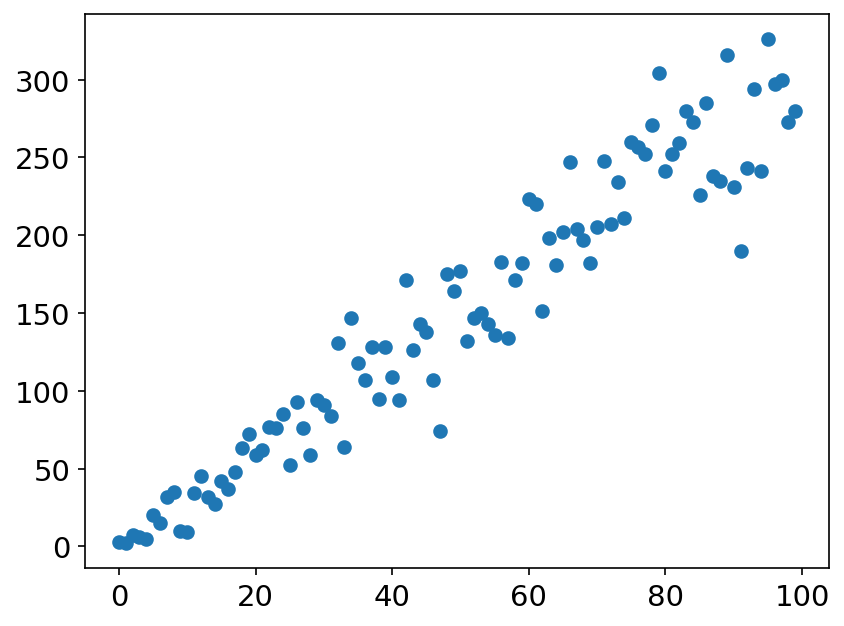

In [4]:
plt.scatter(x, yp);

### Pregunta

De acuerdo al gráfico anterior:
- ¿Los datos siguen una tendencia aproximadamente lineal?

R: Sí, se puede apreciar una relación lineal en los datos.

- ¿La dispersión alrededor de la recta parece constante para todos los valores de \(x\)?

R: No, la disperción aumenta a medida que x crece.

- ¿Qué podría implicar esto al mirar residuos más adelante?

R: Que los errores no tienen una varianza constante.

In [5]:
model = linear_model.LinearRegression()

#### Ajuste con regresión lineal

Ajustaremos un modelo de la forma:

$$
\hat{y} = \beta_0 + \beta_1 x
$$

En `sklearn`, cuando tenemos una sola feature, necesitamos escribir `x` como una matriz de forma `(n_samples, 1)`. Por eso usamos:

```python
x.reshape(-1, 1)

In [6]:
model.fit(x.reshape(-1, 1), yp)

LinearRegression()

In [7]:
slope = model.coef_[0]
intercept = model.intercept_

print(f"Intercepto beta_0 = {intercept:.3f}")
print(f"Pendiente beta_1 = {slope:.3f}")

Intercepto beta_0 = -0.126
Pendiente beta_1 = 3.025


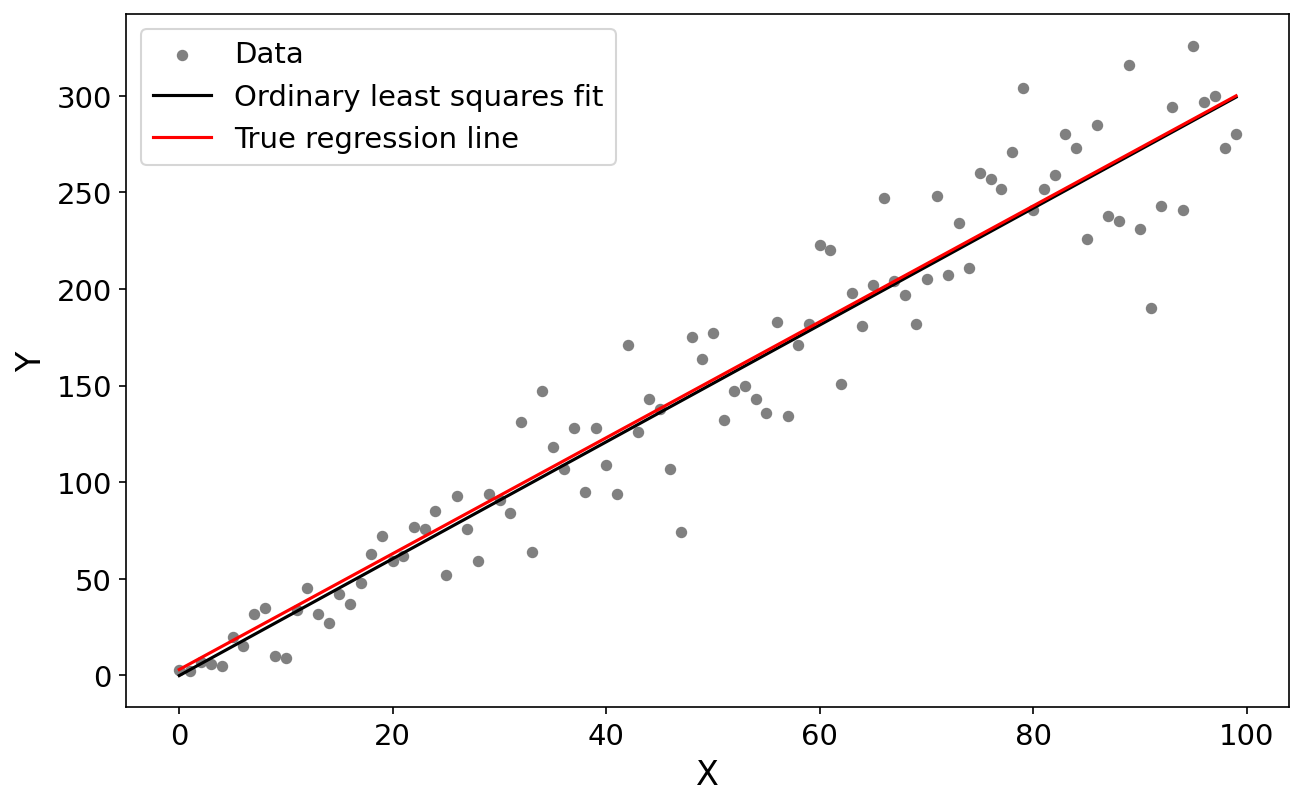

In [8]:
plt.figure(figsize = (10,6))
plt.scatter(x,yp, s = 20, c = 'gray', label = 'Data')
plt.plot(x, slope*x + intercept, c ='k', label = 'Ordinary least squares fit')
plt.plot(x, 3*x + 3, c = 'r', label = 'True regression line')
plt.legend(fontsize = 14)
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

### Pregunta

Compara los coeficientes ajustados con los valores verdaderos $\beta_0=3$ y $\beta_1=3$
-  ¿Son exactamente iguales? ¿Por qué?

R: No son exactamente iguales, ya que como el modelo se ajusta para minimizar el error de la muestra, los coeficientes estimados varían ligeramente.

-  ¿Qué representa físicamente/matemáticamente la pendiente en este modelo?

R: La tasa de cambio. Cuanto cambia la variable $y$ a medida que aumenta la variable $x$.

#### Solución analítica de mínimos cuadrados

Para regresión lineal simple, la pendiente que minimiza el MSE puede escribirse como:

$$
\beta_1 =
\frac{\sum_i (x_i-\bar{x})(y_i-\bar{y})}
{\sum_i (x_i-\bar{x})^2}
$$

y luego:

$$
\beta_0 = \bar{y} - \beta_1\bar{x}
$$

**Implemente en el código para calcular a partir de la solución analítica los coeficientes y compare**

In [9]:
x_mean = np.mean(x)
yp_mean = np.mean(yp)

beta1 = np.sum((x - x_mean) * (yp - yp_mean)) / np.sum((x - x_mean)**2)
beta0 = yp_mean - beta1 * x_mean

print(f"Beta_0 analítico = {beta0:.3f}")
print(f"Beta_1 analítico = {beta1:.3f}")

Beta_0 analítico = -0.126
Beta_1 analítico = 3.025


#### Evaluación del modelo: validación cruzada y métricas

Ahora aplicamos una idea que ya usamos en clasificación: validar el modelo en distintos subconjuntos de datos.

Por defecto, `LinearRegression.score()` devuelve \(R^2\), no accuracy.

Podemos ver todos los scorers implementados en sklearn

In [10]:
from sklearn.metrics import get_scorer_names
print(get_scorer_names())

['accuracy', 'adjusted_mutual_info_score', 'adjusted_rand_score', 'average_precision', 'balanced_accuracy', 'completeness_score', 'd2_absolute_error_score', 'explained_variance', 'f1', 'f1_macro', 'f1_micro', 'f1_samples', 'f1_weighted', 'fowlkes_mallows_score', 'homogeneity_score', 'jaccard', 'jaccard_macro', 'jaccard_micro', 'jaccard_samples', 'jaccard_weighted', 'matthews_corrcoef', 'mutual_info_score', 'neg_brier_score', 'neg_log_loss', 'neg_max_error', 'neg_mean_absolute_error', 'neg_mean_absolute_percentage_error', 'neg_mean_gamma_deviance', 'neg_mean_poisson_deviance', 'neg_mean_squared_error', 'neg_mean_squared_log_error', 'neg_median_absolute_error', 'neg_negative_likelihood_ratio', 'neg_root_mean_squared_error', 'neg_root_mean_squared_log_error', 'normalized_mutual_info_score', 'positive_likelihood_ratio', 'precision', 'precision_macro', 'precision_micro', 'precision_samples', 'precision_weighted', 'r2', 'rand_score', 'recall', 'recall_macro', 'recall_micro', 'recall_samples'

#### Implemente una validación cruzada con Kfold

y encuentre los resultados para las métricas R^2, 'neg_mean_absolute_error'  (MAE) y 'neg_mean_squared_error' (MSE)

Para los estimadores de la performance del modelo del tipo "error" siempre queremos que sean pequeños (menor error, mejor modelo). Pero en sklearn, reciben un signo negativo, como neg_mean_squared_error, para mantener la consistencia de "alto puntaje=mejor" de los scorers

In [11]:
n_splits = 5 # Número de folds
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# La función cross_validate permite calcular múltiples métricas y retornar tanto los scores de entrenamiento como de test.
# Necesitamos reformar x para que tenga la forma (n_samples, 1).
X_reshaped = x.reshape(-1, 1)

In [12]:
scores_r2 = cross_validate(model, X_reshaped, yp, cv=kf, scoring='r2', return_train_score=True)
print(f"R2 test : {scores_r2['test_score'].mean():.3f} ± {scores_r2['test_score'].std():.3f}")
print(f"R2 train: {scores_r2['train_score'].mean():.3f} ± {scores_r2['train_score'].std():.3f}")

R2 test : 0.903 ± 0.059
R2 train: 0.925 ± 0.007


In [13]:
scores_mse = cross_validate(model, X_reshaped, yp, cv=kf, scoring='neg_mean_squared_error')
scores_mae = cross_validate(model, X_reshaped, yp, cv=kf, scoring='neg_mean_absolute_error')

print(f"MSE test: {-scores_mse['test_score'].mean():.3f} ± {scores_mse['test_score'].std():.3f}")
print(f"MAE test: {-scores_mae['test_score'].mean():.3f} ± {scores_mae['test_score'].std():.3f}")

MSE test: 633.964 ± 179.773
MAE test: 19.067 ± 3.297


**Haga un gráfico de los residuos $r_i=y_i-\hat{y}_i$**

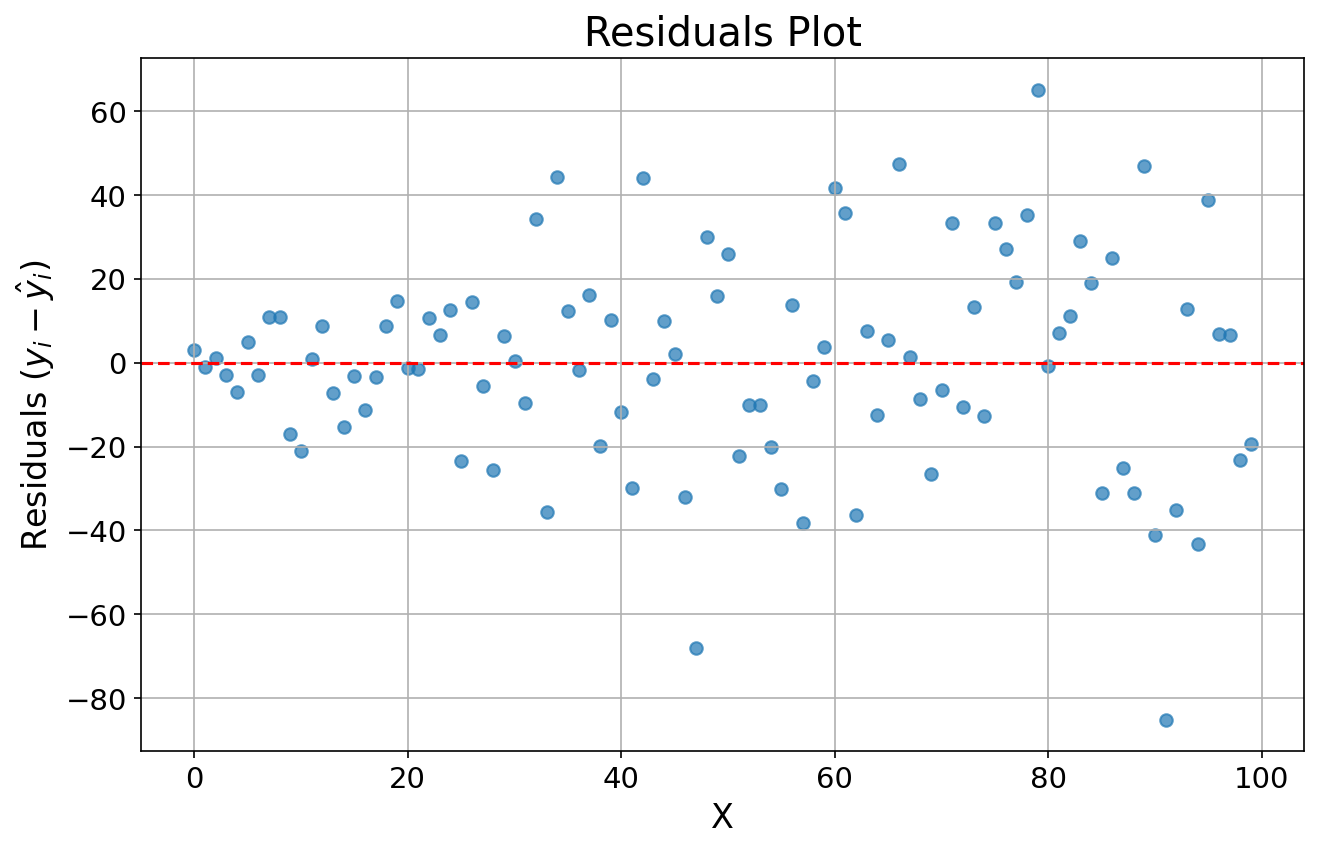

In [14]:
y_pred = model.predict(X_reshaped)
residuals = yp - y_pred.flatten()

plt.figure(figsize=(10,6))
plt.scatter(x, residuals, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('X')
plt.ylabel(r'Residuals ($y_i - \hat{y}_i$)')
plt.title('Residuals Plot')
plt.grid(True)
plt.show()

#### Pregunta
-  ¿Los residuos parecen distribuidos aleatoriamente alrededor de cero?

R: Sí. Se ve que están distribuidos aleatoriamente por encima y debajo del 0, lo que significa que el modelo captura adecuadamente la tendencia principal de los datos.

-  ¿La dispersión de los residuos cambia con $x$?

R: Sí cambia. No es constante, aumenta a medida que $x$ crece.

-  ¿Qué nos dice esto sobre el modelo y/o sobre cómo fueron generados los datos?

R: Nos dice que el modelo tiene una varianza no constante. Y demuestra que los datos se generan con un ruido que depende del valor de $x$.

### ¿Qué ocurre si agregamos outliers?

In [15]:
np.random.seed(12) # fijada la semilla
out = np.random.choice(100,15) #seleccionamos 15 índices de outliers
yp_wo = np.copy(yp)
np.random.seed(12) #fijada
yp_wo[out] = yp_wo[out] + 5*np.random.rand(15)*yp[out]

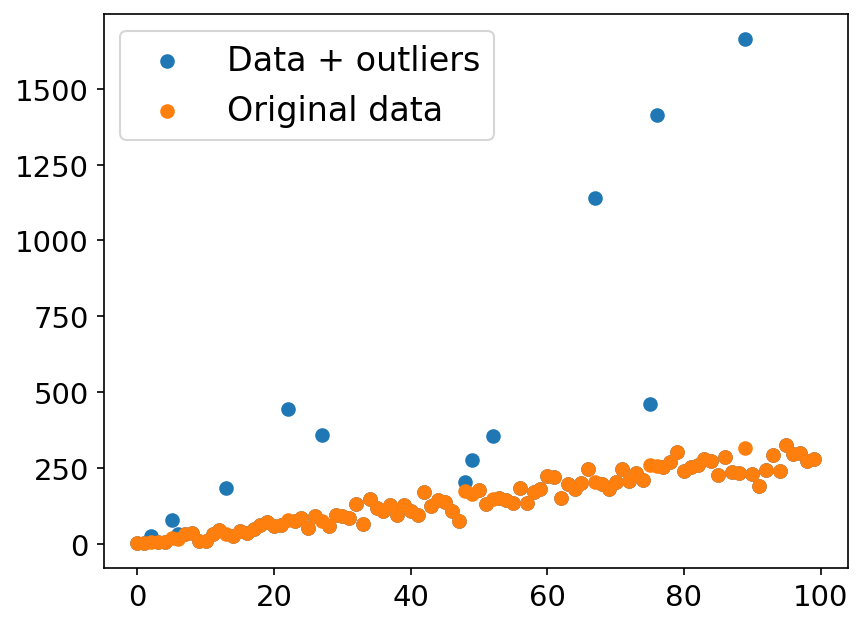

In [16]:
plt.scatter(x,yp_wo, label = 'Data + outliers')
plt.scatter(x,yp, label = 'Original data')
plt.legend();

Intercepto beta_0 (con outliers) = 1.548
Pendiente beta_1 (con outliers) = 3.978


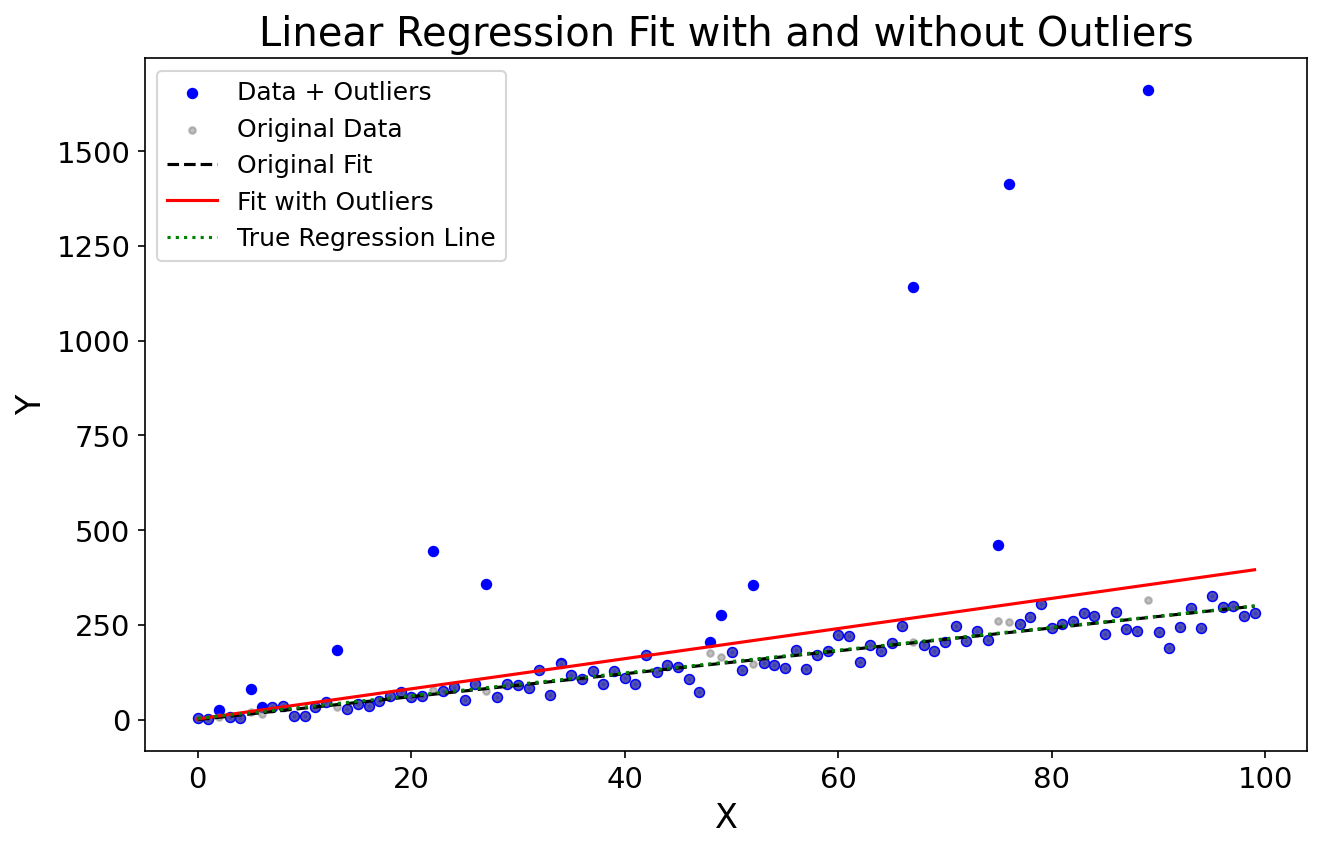

In [17]:
model_with_outliers = linear_model.LinearRegression()
model_with_outliers.fit(X_reshaped, yp_wo)

# Get the new coefficients
new_slope = model_with_outliers.coef_[0]
new_intercept = model_with_outliers.intercept_

print(f"Intercepto beta_0 (con outliers) = {new_intercept:.3f}")
print(f"Pendiente beta_1 (con outliers) = {new_slope:.3f}")

# Plot the data and regression lines
plt.figure(figsize = (10,6))
plt.scatter(x, yp_wo, s = 20, c = 'blue', label = 'Data + Outliers')
plt.scatter(x, yp, s = 10, c = 'gray', alpha=0.5, label = 'Original Data')
plt.plot(x, slope*x + intercept, c ='k', linestyle='--', label = 'Original Fit')
plt.plot(x, new_slope*x + new_intercept, c = 'red', label = 'Fit with Outliers')
plt.plot(x, 3*x + 3, c = 'green', linestyle=':', label = 'True Regression Line')
plt.legend(fontsize = 12)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Linear Regression Fit with and without Outliers')
plt.show()

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --- Metrics for the original model (without outliers) ---
y_pred_original = model.predict(X_reshaped)
mae_original = mean_absolute_error(yp, y_pred_original)
mse_original = mean_squared_error(yp, y_pred_original)
rmse_original = np.sqrt(mse_original)
r2_original = r2_score(yp, y_pred_original)

print("Métricas para el modelo original (sin outliers):")
print(f"  MAE: {mae_original:.3f}")
print(f"  MSE: {mse_original:.3f}")
print(f"  RMSE: {rmse_original:.3f}")
print(f"  R^2: {r2_original:.3f}")

print("\n" + "-"*50 + "\n")

# --- Metrics for the model with outliers ---
y_pred_outliers = model_with_outliers.predict(X_reshaped)
mae_outliers = mean_absolute_error(yp_wo, y_pred_outliers)
mse_outliers = mean_squared_error(yp_wo, y_pred_outliers)
rmse_outliers = np.sqrt(mse_outliers)
r2_outliers = r2_score(yp_wo, y_pred_outliers)

print("Métricas para el modelo con outliers:")
print(f"  MAE: {mae_outliers:.3f}")
print(f"  MSE: {mse_outliers:.3f}")
print(f"  RMSE: {rmse_outliers:.3f}")
print(f"  R^2: {r2_outliers:.3f}")

Métricas para el modelo original (sin outliers):
  MAE: 18.939
  MSE: 617.759
  RMSE: 24.855
  R^2: 0.925

--------------------------------------------------

Métricas para el modelo con outliers:
  MAE: 90.514
  MSE: 43259.082
  RMSE: 207.988
  R^2: 0.234


#### Ajuste el modelo de regresión lineal para los datos con outliers

Responda:
- Compare visualmente el ajuste antes y después de agregar outliers. ¿La recta cambia mucho? ¿Hacia dónde se mueve?

R: Si cambia. La recta se mueve en dirección en la que se encuentran los outliers, alejandose de la tendencia central.

- Compara los coeficientes $\beta_0$ y $\beta_1$ del modelo con y sin outliers.  ¿Cuál cambia más: el intercepto o la pendiente?

R: La pendiente.

- Compara las métricas MAE, MSE, RMSE y $R^2$ antes y después de agregar outliers. ¿Qué métrica se ve más afectada?

R: Si bien todas cambian, naturalmente, las que más se ven afectadas son el MSE y el RMSE. Mientras que el $R^2$

- ¿Por qué el MSE/RMSE suele ser más sensible a outliers que el MAE?

R: Porque elevan los errores al cuadrado, por lo que al tener un residuo grande, éste error se magnifica, penalizando el modelo más que el MAE.

- ¿Todos los outliers afectan de la misma manera al modelo? Observa si los puntos atípicos están lejos en $y$, lejos en $x$, o en ambos.

R: No, afectan más los que están más alejados de $x$ e $y$, ya que influyen más en el cambio de la pendiente.

- ¿Dirías que el modelo con outliers está aprendiendo la tendencia general de los datos o está siendo “tirado” por algunos puntos extremos? Justifica.

R: Está siendo tirado por los puntos extremos. Debido a que el modelo busca minimizar el error cuadrático, prefiere desviar la recta para reducir los errores grandes de esos outliers, lo que arruina el buen ajuste que tenía el modelo con los valores originales.

- Si este fuera un dataset real, ¿eliminarías los outliers automáticamente? Explica qué revisarías antes de decidir.

R: Primero investigaría si éstos outliers pueden significar algo físicamente. Si no es el caso, los borraría. Pero si no, lo correcto sería buscar un modelo que se ajuste bien considerandolos.

In [19]:
model_outliers = linear_model.LinearRegression()
model_outliers.fit(X_reshaped, yp_wo)

LinearRegression()

Del resultado del modelo lineal para estos datos con outliers, guarde los coeficientes encontrados en un array llamado `theta_ne`

In [20]:
theta_ne = np.array([model_outliers.intercept_, model_outliers.coef_[0]])
print(f"Theta_ne (intercept, slope) = {theta_ne}")

Theta_ne (intercept, slope) = [1.54811881 3.97842184]


Esto es la solución usando el modelo y la **ecuación normal**

### Ahora implementaremos 3 métodos de gradient descent: batch, estocástico y mini-batch

En esta sección ajustamos una regresión lineal usando Gradient Descent en vez de usar directamente `LinearRegression`. Compararemos con los resultados encontrados en la regresión con outliers.




Agregaremos $x_0=1$ a cada instancia, este es el término de bias ($\beta_0$) y se usa para escribir la solución en la forma de multiplicación de matrices

$y=X\cdot \theta$

donde $\theta$ es el vector de coeficientes que incluye el término $\beta_0$  (término de bias) y $\beta_1, \beta_2, \beta_3,..., \beta_n$

In [23]:
X = np.c_[np.ones((100, 1)), x]

print(X.shape) #la forma es el número de instancias x número de parámetros


(100, 2)


Podemos calcular la pérdida asociada con la ecuación normal, usando la expresión

$\text{MSE} = \frac{1}{m}\|X\cdot \theta - y \|^2$

In [24]:
loss_ne = np.mean((X.dot(theta_ne) - yp_wo.reshape(-1,1))**2)

### Batch GD

In [25]:
np.random.seed(10)

eta = 0.0001 #learning step (valor pequeño asegura convergencia, aunque lenta)
n_iterations = 1000 #puede cambiar este valor!!
m = 100 #número de instancias

theta_path_bgd = [] #arreglo para guardar los valores de los parámetros en cada iteración

theta = np.random.randn(2,1) #inicializamos con valores aleatorios

for iteration in range(n_iterations):
    gradients = 2/m * X.T.dot(X.dot(theta) - yp_wo.reshape(-1,1)) #gradiente de la función de pérdida respecto a theta
    theta = theta - eta * gradients #actualiza los valores de theta, en cada cálculo del gradiente, en cada paso
    theta_path_bgd.append(theta) #

theta_path_bgd = np.array(theta_path_bgd) #guardamos esos valores (útil para una visualización)

theta_bgd = theta #resultado final

In [26]:
theta_bgd

array([[1.38909891],
       [3.98081931]])

In [27]:
loss_bgd = np.sum(1/m*(X.dot(theta_bgd) - yp_wo.reshape(-1,1))**2)

In [28]:
loss_bgd

np.float64(43259.08804185896)

In [29]:
(loss_ne-loss_bgd)/loss_ne*100 #diferencia porcentual con la ecuación normal

np.float64(37.87842821341626)

###  GD estocástico

In [30]:
np.random.seed(10) #

theta = np.random.randn(2,1)  #inicializa los parámetros

eta = 0.000005 #learning step, valor más pequeño evita saltos muy grandes

n_iterations = 10000 #necesitamos más iteraciones en este caso

theta_path_sgd = []

for epoch in range(n_iterations):

        random_index = np.random.randint(m) #índice aleatorio

        x_one = X[random_index:random_index+1] #sólo se selecciona una instancia del conjunto de datos (m es la cantidad total)

        y_one = yp_wo[random_index:random_index+1]

        gradients = 2 * x_one.T.dot(x_one.dot(theta) - y_one)
        theta = theta - eta * gradients
        theta_path_sgd.append(theta)

theta_path_sgd = np.array(theta_path_sgd)

theta_sgd = theta

In [31]:
theta_sgd

array([[1.3552955 ],
       [4.17721319]])

In [32]:
loss_sgd = np.sum(1/m*(X.dot(theta_sgd) - yp_wo.reshape(-1,1))**2)

In [33]:
loss_sgd

np.float64(43385.08132655123)

In [34]:
(loss_ne-loss_sgd)/loss_ne*100 #diferencia porcentual con la ecuación normal

np.float64(37.69749742559972)

### Mini batch GD

In [35]:
# See also implementation notes here: https://sebastianraschka.com/faq/docs/sgd-methods.html

np.random.seed(10)

theta = np.random.randn(2,1)

eta = 0.000005

n_iterations = 1000

theta_path_mgd = []

minibatch_size = 10

for epoch in range(n_iterations):

    shuffled_indices = np.random.permutation(m) #se desordena el arreglo para seleccionar distintos mini-batches

    X_shuffled = X[shuffled_indices]

    y_shuffled = yp_wo.reshape(-1,1)[shuffled_indices]

    xi = X_shuffled[:minibatch_size] #subset aleatorio para calcular el gradiente

    yi = y_shuffled[:minibatch_size]

    gradients = 2/minibatch_size * xi.T.dot(xi.dot(theta) - yi)

    theta = theta - eta * gradients

    theta_path_mgd.append(theta)

theta_path_mgd = np.array(theta_path_mgd)

theta_mgd = theta

print(theta_mgd)

[[1.38191988]
 [4.25542902]]


In [36]:
theta_mgd

array([[1.38191988],
       [4.25542902]])

In [37]:
loss_mgd = np.sum(1/m*(X.dot(theta_mgd) - yp_wo.reshape(-1,1))**2)

In [38]:
loss_mgd

np.float64(43506.50418469318)

In [39]:
(loss_ne-loss_mgd)/loss_ne*100 #diferencia porcentual con la ecuación normal

np.float64(37.52312993104463)

#### Comparación de GD
Veamos el camino que siguió cada método de GD que implementamos. El color más oscuro indica pasos posteriores

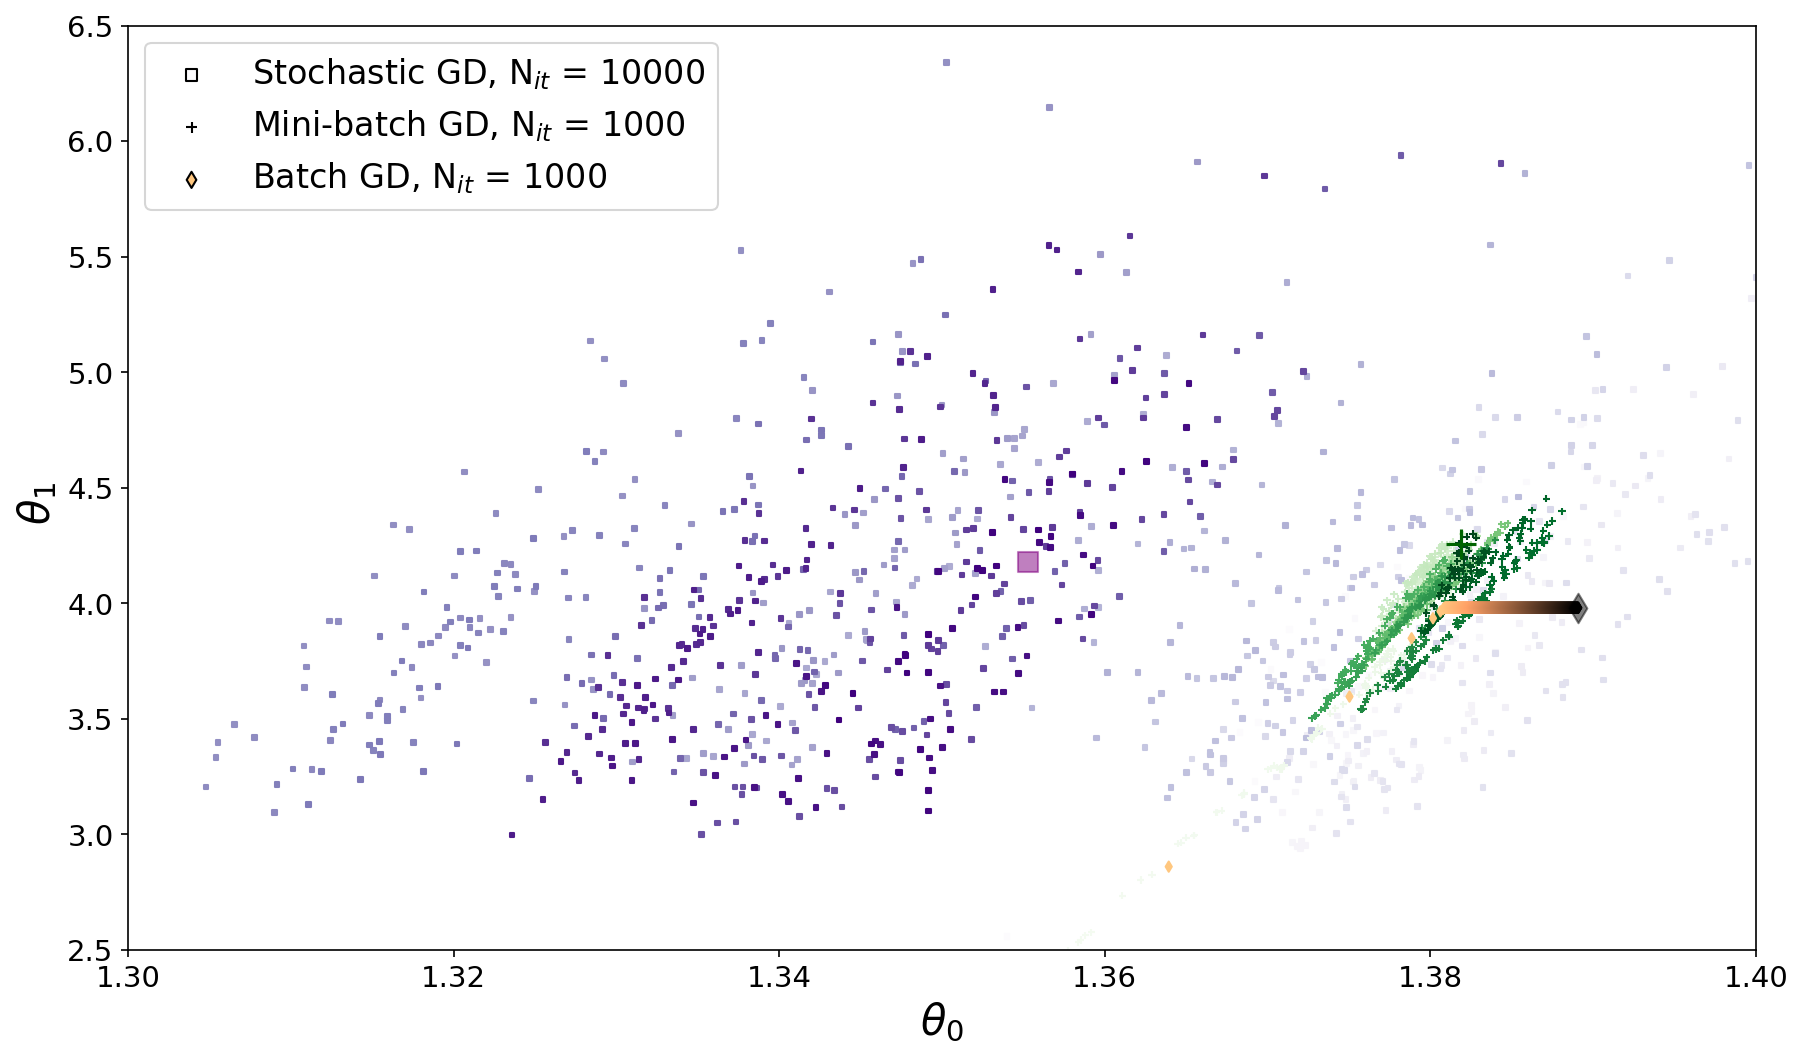

In [40]:
plt.figure(figsize=(14,8))

plt.scatter(theta_path_sgd[::10, 0].flatten(), theta_path_sgd[::10, 1].flatten(), marker = 's', s = 5, \
         label="Stochastic GD, N$_{it}$ = 10000", c = np.arange(1000), cmap=plt.cm.Purples)
plt.scatter(theta_path_mgd[:, 0].flatten(), theta_path_mgd[:, 1].flatten(), marker = "+", s = 12, linewidth=1, \
            label="Mini-batch GD, N$_{it}$ = 1000", c = np.arange(1000), cmap=plt.cm.Greens)
plt.scatter(theta_path_bgd[:, 0].flatten(), theta_path_bgd[:, 1].flatten(), marker = "d", s = 12, linewidth=1, \
            label="Batch GD, N$_{it}$ = 1000", c = np.arange(1000,0,-1), cmap=plt.cm.copper)

plt.scatter(theta_sgd[0],theta_sgd[1], marker = "s", s = 100, color = 'Purple', alpha = 0.5)
plt.scatter(theta_mgd[0],theta_mgd[1], marker = "+", s = 200, color = 'DarkGreen', alpha = 1)
plt.scatter(theta_bgd[0],theta_bgd[1], marker = "d", s = 100, color = 'k', alpha = 0.5)

legend = plt.legend(loc="upper left", fontsize=16)


for i in range(3):

    legend.legend_handles[i].set_color('k')
    legend.legend_handles[i]._sizes = [30]

plt.xlabel(r"$\theta_0$", fontsize=20)
plt.ylabel(r"$\theta_1$   ", fontsize=20)

plt.axis([1.3, 1.4, 2.5, 6.5])

#plt.savefig('AllThePaths.png', dpi = 300)
plt.show()

Final theta with small eta (1e-05): [1.3816682  3.98093134]
Final theta with reasonable eta (0.0001): [-1.33455195  4.02188255]
Final theta with large eta (0.001): [nan nan]


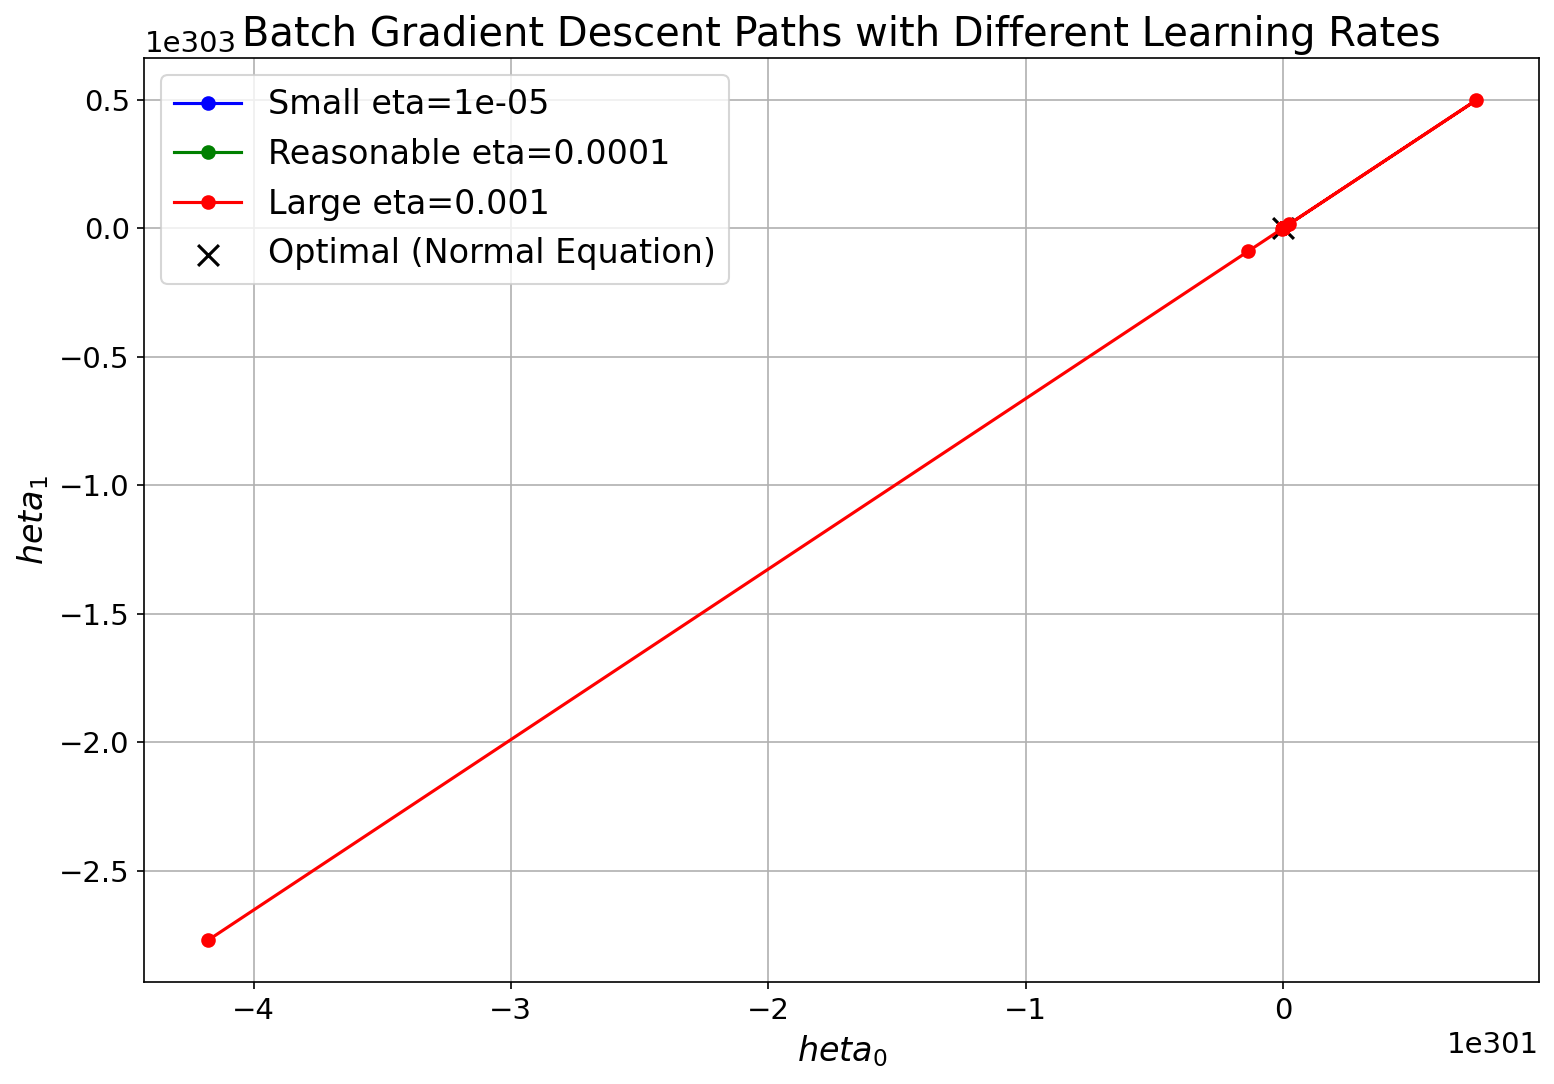

In [42]:
np.random.seed(10)

# --- Small learning rate ---
eta_small = 0.00001
n_iterations = 1000
m = 100
theta_path_bgd_small = []
theta_small = np.random.randn(2,1)
for iteration in range(n_iterations):
    gradients = 2/m * X.T.dot(X.dot(theta_small) - yp_wo.reshape(-1,1))
    theta_small = theta_small - eta_small * gradients
    theta_path_bgd_small.append(theta_small)
theta_path_bgd_small = np.array(theta_path_bgd_small)

# --- Reasonable learning rate (from previous cell) ---
eta_reasonable = 0.0001
n_iterations = 1000
m = 100
theta_path_bgd_reasonable = []
theta_reasonable = np.random.randn(2,1)
for iteration in range(n_iterations):
    gradients = 2/m * X.T.dot(X.dot(theta_reasonable) - yp_wo.reshape(-1,1))
    theta_reasonable = theta_reasonable - eta_reasonable * gradients
    theta_path_bgd_reasonable.append(theta_reasonable)
theta_path_bgd_reasonable = np.array(theta_path_bgd_reasonable)

# --- Large learning rate ---
eta_large = 0.001
n_iterations = 1000
m = 100
theta_path_bgd_large = []
theta_large = np.random.randn(2,1)
for iteration in range(n_iterations):
    gradients = 2/m * X.T.dot(X.dot(theta_large) - yp_wo.reshape(-1,1))
    theta_large = theta_large - eta_large * gradients
    theta_path_bgd_large.append(theta_large)
theta_path_bgd_large = np.array(theta_path_bgd_large)

print(f"Final theta with small eta ({eta_small}): {theta_path_bgd_small[-1].flatten()}")
print(f"Final theta with reasonable eta ({eta_reasonable}): {theta_path_bgd_reasonable[-1].flatten()}")
print(f"Final theta with large eta ({eta_large}): {theta_path_bgd_large[-1].flatten()}")

# Plotting the paths
plt.figure(figsize=(12, 8))
plt.plot(theta_path_bgd_small[:, 0], theta_path_bgd_small[:, 1], "b-o", label=f"Small eta={eta_small}")
plt.plot(theta_path_bgd_reasonable[:, 0], theta_path_bgd_reasonable[:, 1], "g-o", label=f"Reasonable eta={eta_reasonable}")
plt.plot(theta_path_bgd_large[:, 0], theta_path_bgd_large[:, 1], "r-o", label=f"Large eta={eta_large}")

plt.scatter(theta_ne[0], theta_ne[1], color='k', marker='x', s=100, label='Optimal (Normal Equation)')

plt.xlabel(r"$	heta_0$")
plt.ylabel(r"$	heta_1$")
plt.title("Batch Gradient Descent Paths with Different Learning Rates")
plt.legend()
plt.grid(True)
plt.show()

### Preguntas

1. Identifica en el código de mini batch GD dónde ocurre cada paso:

   - cálculo de las predicciones: `xi.dot(theta)`
   - cálculo del error o residuo: `xi.dot(theta) - yi`
   - cálculo del gradiente: gradients = `2/minibatch_size * xi.T.dot(xi.dot(theta) - yi)`
   - actualización de los parámetros: `theta = theta - eta * gradients`

2. ¿Qué representan los parámetros $\theta_0$ y $\theta_1$ en este modelo?

R: $\theta_0$ representa el intercepto, y $\theta_1$ representa la pendiente.

3. Compara los parámetros encontrados por Gradient Descent con los obtenidos mediante `LinearRegression`. ¿Son iguales o parecidos? ¿Por qué no necesariamente coinciden exactamente?

R: Son parecidos, pero no exactamente iguales. La diferencia radica en que mientras `LinearRegression` calcula la solución analítica exacta, `Gradient Descent` lo hace mediante iteraciones que se van aproximando paso a paso a la solución, por lo que su convergencia va a depender de más parámetros.

4. Cambia el learning rate $\eta$. Prueba al menos tres valores: uno pequeño, uno razonable y uno demasiado grande. ¿Qué ocurre en cada caso?

R: Hemos probado con tres valores de learning rate para Batch Gradient Descent, y observamos lo siguiente:

*   **Learning Rate Pequeño ($\eta = 0.00001$):** El algoritmo avanza muy lentamente. Aunque se mueve en la dirección correcta, la convergencia es muy gradual y podría requerir una gran cantidad de iteraciones para alcanzar el óptimo. Los parámetros finales obtenidos fueron `[1.3816682, 3.98093134]`.

*   **Learning Rate Razonable ($\eta = 0.0001$):** Con este valor, el algoritmo avanza más rápidamente hacia el mínimo. Sin embargo, en esta ejecución, los parámetros finales obtenidos fueron `[-1.33455195, 4.02188255]`. Aunque es más rápido que el learning rate pequeño, la solución final para el intercepto se desvía considerablemente de la solución óptima (ecuación normal), posiblemente debido a la inicialización aleatoria de los parámetros o a pequeñas oscilaciones que lo llevaron a un punto ligeramente diferente dentro del número de iteraciones.

*   **Learning Rate Demasiado Grande ($\eta = 0.001$):** El algoritmo diverge. Los pasos de actualización son tan grandes que sobrepasan el mínimo del costo, haciendo que la función de costo aumente en lugar de disminuir. Los parámetros se vuelven `NaN` (Not a Number), lo que indica que el modelo no ha podido converger a una solución válida.

5. Explica con tus palabras por qué la actualización tiene un signo menos: $\theta \leftarrow \theta - \eta \nabla L$

R: El signo menos es fundamental porque el gradiente ($\nabla L$) apunta siempre en la dirección de mayor aumento de la función de pérdida ($L$). Como el objetivo de Gradient Descent es minimizar esta función de pérdida, necesitamos movernos en la dirección opuesta al gradiente. Restar el gradiente nos asegura que estamos "bajando la colina" hacia el mínimo de la función de costo.

6. En la solución analítica derivamos e igualamos a cero. En Gradient Descent no resolvemos directamente la ecuación.  ¿Qué hacemos en cambio?

R: Resolvemos iterativamente paso a paso, comenzando con valores aleatorios y usando la pendiente local (gradiente) para corregir los parámetros repetitivamente, hasta que el error deja de disminuir de manera sustancial.

7. Compara Batch Gradient Descent, Stochastic Gradient Descent y Mini-batch Gradient Descent.

   - ¿Cuál usa todos los datos en cada actualización? R: `Batch GD`
   - ¿Cuál actualiza los parámetros con más ruido? R: `Stochastic GD`
   - ¿Cuál parece converger de forma más suave? R: `Batch GD`
